In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def get_difference(
    file_path,
    side1_products,
    side1_scalars,
    side2_products,
    side2_scalars,
) -> pd.DataFrame:

    if len(side1_products) != len(side1_scalars):
        raise ValueError("side1_products and side1_scalars must have the same length")
    if len(side2_products) != len(side2_scalars):
        raise ValueError("side2_products and side2_scalars must have the same length")

    df = pd.read_csv(file_path, sep=";")

    # Clean numeric columns
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "product", "mid_price"])

    # Build a pivot table: rows = timestamp, columns = product, values = mid_price
    # If there are duplicates for a timestamp/product, take the last observed value.
    pivot = df.pivot_table(
        index="timestamp",
        columns="product",
        values="mid_price",
        aggfunc="last",
    ).sort_index()

    # Compute weighted sums for each side
    side1_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side1_products, side1_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side1_value = side1_value + pivot[product].fillna(0) * scalar

    side2_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side2_products, side2_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side2_value = side2_value + pivot[product].fillna(0) * scalar

    difference = side1_value - side2_value
    difference_df = difference.reset_index()
    difference_df.columns = ["timestamp", "mid_price"]
    return difference_df

In [84]:
def plot_difference(
        difference: pd.DataFrame,
        title="Basket Premium / Difference vs Timestamp",
    ):
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(difference["timestamp"], difference["mid_price"], linewidth=0.8)
    plt.axhline(difference["mid_price"].mean(), linestyle="--", linewidth=0.8)
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Price Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [85]:
def auto_correlation(df: pd.DataFrame, column1: str, column2: str, lag: int = 1) -> float:
    if column1 not in df.columns:
        raise KeyError(f"df must contain a '{column1}' column")
    if column2 not in df.columns:
        raise KeyError(f"df must contain a '{column2}' column")

    tmp = df[[column1, column2]].copy().sort_values(column1)
    x = tmp[column2]
    y = tmp[column2].shift(lag)
    return x.corr(y)

FIRST HALF
---
Autocor: -0.012835328867929997
Autocor: -0.012835328867929997


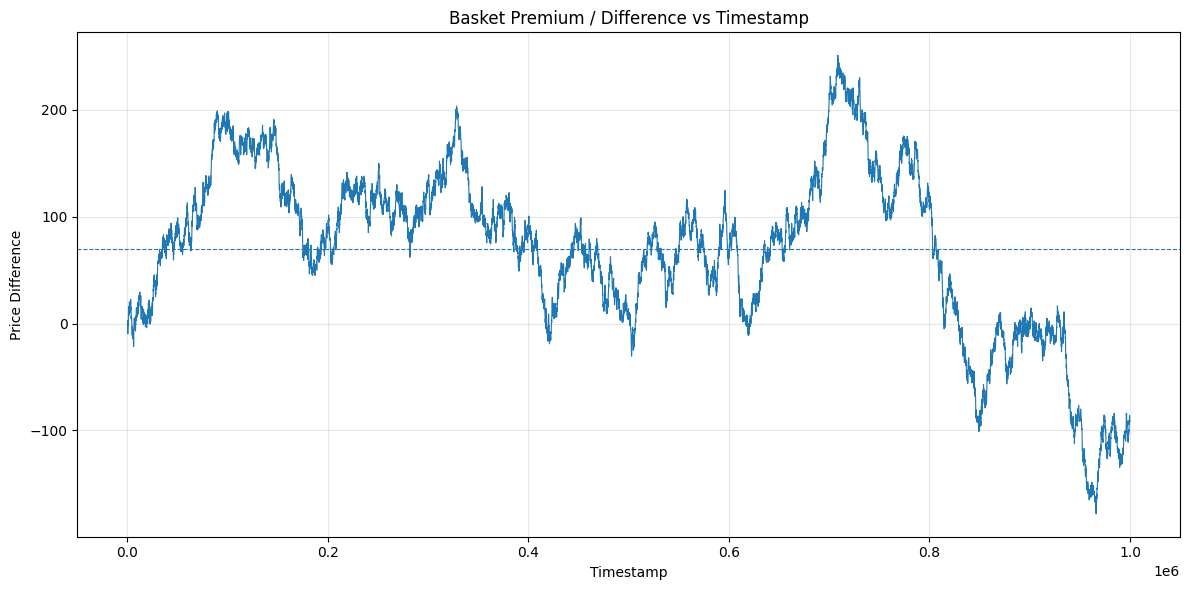

Autocor: 0.004573332253181776
Autocor: 0.004573332253181776


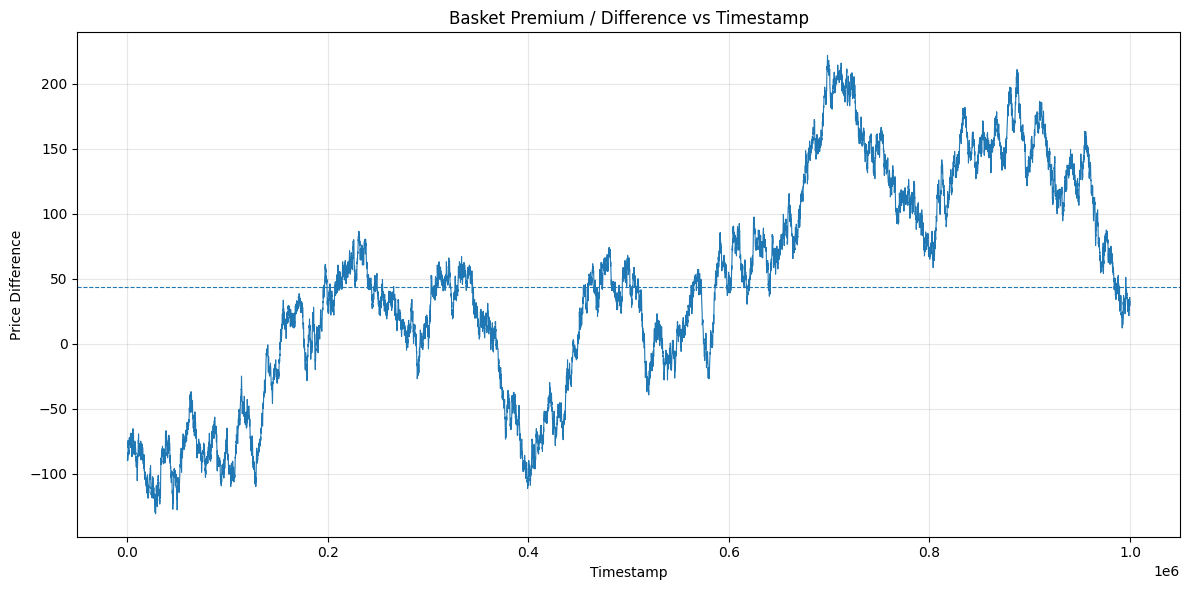

Autocor: 0.0039577405192746115
Autocor: 0.0039577405192746115


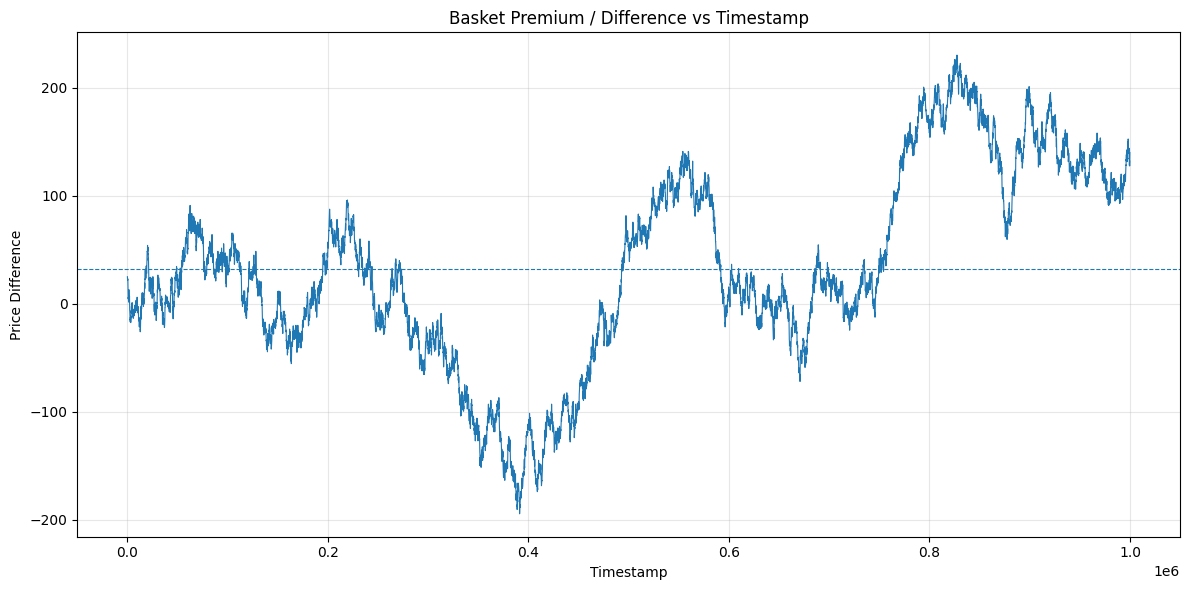

In [104]:
# Example usage:

print("FIRST HALF")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    df = pd.read_csv(file_path, sep=";")

    side1_products = ["PICNIC_BASKET1"]
    side1_scalars = [1]
    side2_products = ["CROISSANTS", "JAMS", "DJEMBES"]
    side2_scalars = [6, 3, 1]
    
    diff_series = get_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars
    )
    diff_series["shifted_price"] = diff_series["mid_price"].shift(-1)
    diff_series["shifted_diff"] = (diff_series["mid_price"].shift(-1) - diff_series["mid_price"])
    # print(diff_series)
    
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_diff", 100))
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_diff", 100))
    plot_difference(diff_series)

SECOND HALF
---
Autocor: -0.019676622570364084


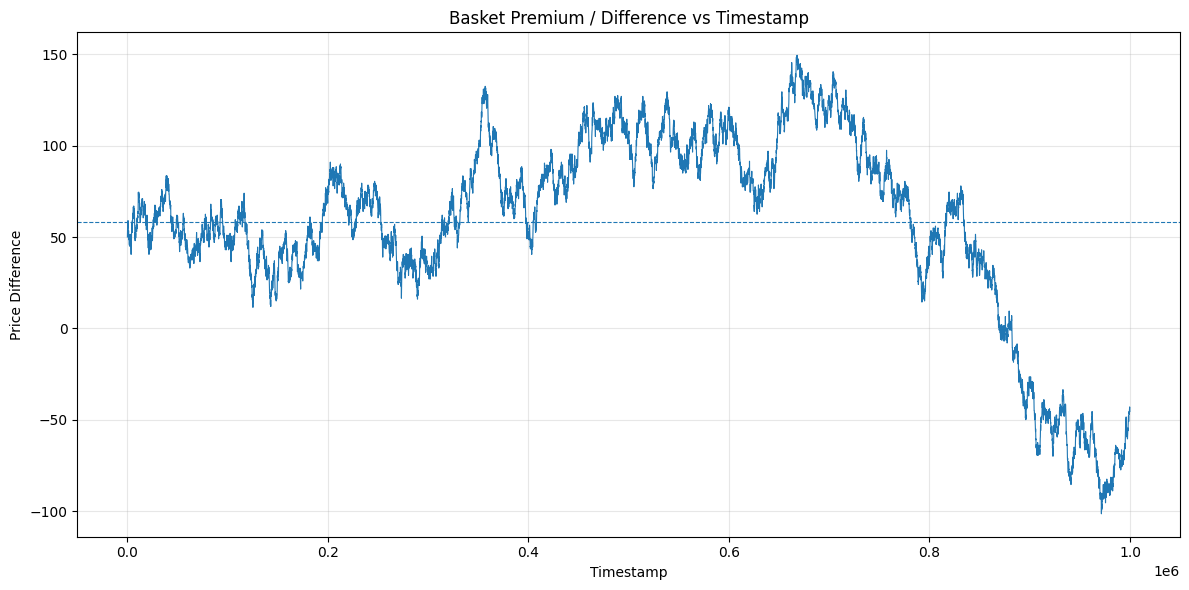

Autocor: 0.002360794944606783


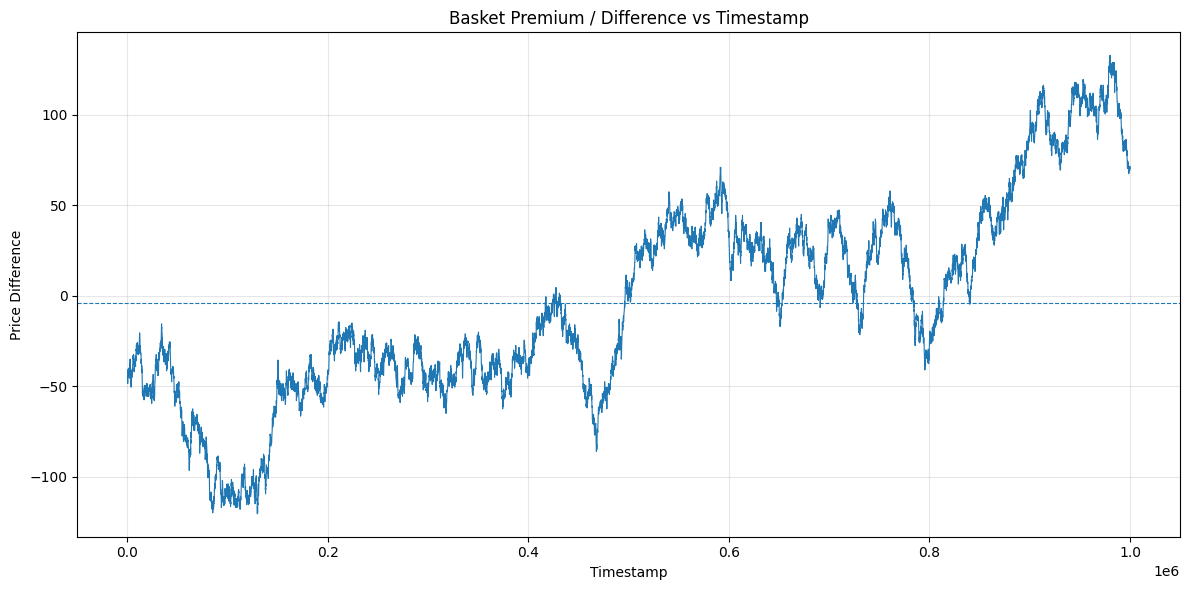

Autocor: -0.022183913775050787


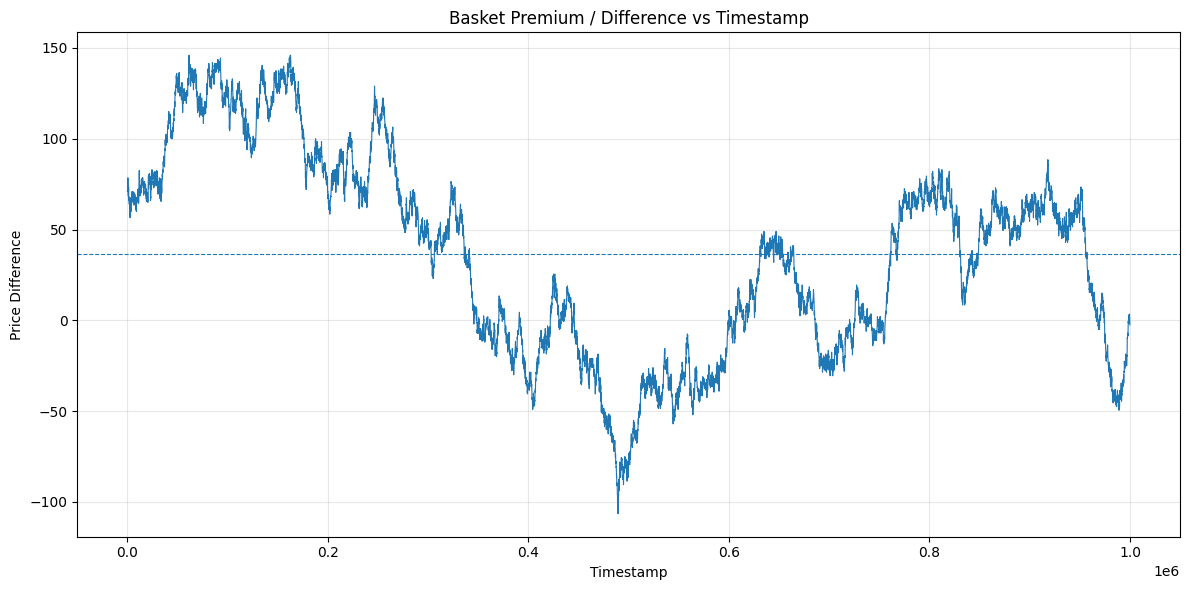

In [ ]:
print("SECOND HALF")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    df = pd.read_csv(file_path, sep=";")

    side1_products = ["PICNIC_BASKET2"]
    side1_scalars = [1]
    side2_products = ["CROISSANTS", "JAMS"]
    side2_scalars = [4, 2]

    diff_series = get_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars
    )
    diff_series["shifted_price"] = diff_series["mid_price"].shift(-1)
    diff_series["shifted_diff"] = (diff_series["mid_price"].shift(-1) - diff_series["mid_price"])
    # print(diff_series)
    
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_price", 100))
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_diff", 100))
    plot_difference(diff_series)

TESTING FIRST + SECOND
---
Autocor: -0.002859446045676948


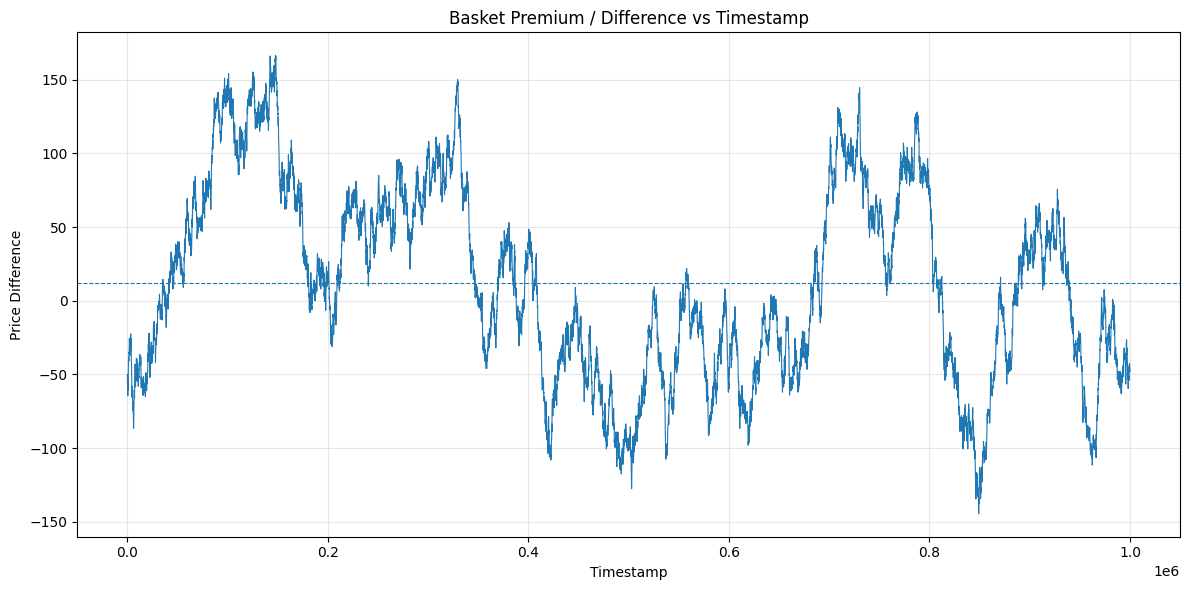

Autocor: 0.0022404115349637602


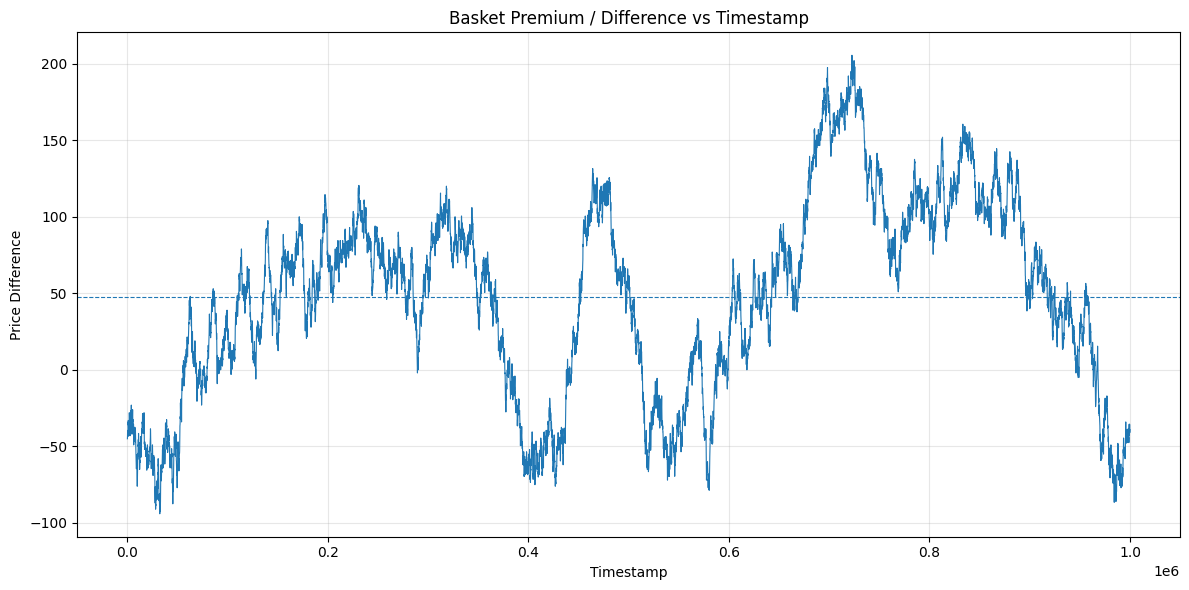

Autocor: -0.0032389031012209054


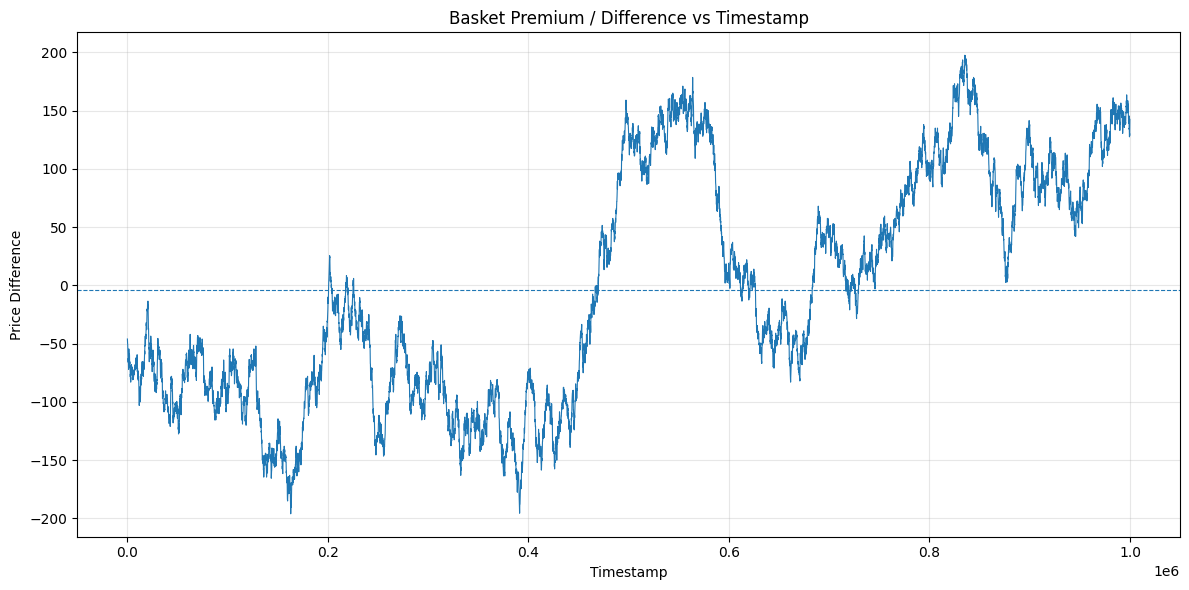

In [ ]:
print("TESTING FIRST + SECOND")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    df = pd.read_csv(file_path, sep=";")

    side1_products = ["PICNIC_BASKET1"]
    side1_scalars = [1]
    side2_products = ["PICNIC_BASKET2", "CROISSANTS", "JAMS", "DJEMBES"]
    side2_scalars = [1, 2, 1, 1]

    diff_series = get_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars
    )
    diff_series["shifted_price"] = diff_series["mid_price"].shift(-1)
    diff_series["shifted_diff"] = (diff_series["mid_price"].shift(-1) - diff_series["mid_price"])
    # print(diff_series)
    
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_price", 100))
    print("Autocor:", auto_correlation(diff_series, "mid_price", "shifted_diff", 100))
    plot_difference(diff_series)

FIRST HALF
---


C:\Users\ishaa\AppData\Local\Temp\ipykernel_25388\3976858650.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df, df])


       timestamp  mid_price  day           product  bid_price_1  bid_volume_1  \
0       -1000000     4304.5 -1.0        CROISSANTS       4304.0         112.0   
1       -1000000     6670.5 -1.0              JAMS       6670.0          66.0   
2       -1000000     2005.5 -1.0         SQUID_INK       2005.0           1.0   
3       -1000000    59289.0 -1.0    PICNIC_BASKET1      59284.0          20.0   
4       -1000000    30609.0 -1.0    PICNIC_BASKET2      30606.0          20.0   
...          ...        ...  ...               ...          ...           ...   
239995   1999900     6520.0  1.0              JAMS       6519.0         204.0   
239996   1999900    10000.0  1.0  RAINFOREST_RESIN       9992.0          34.0   
239997   1999900     1882.0  1.0         SQUID_INK       1880.0          20.0   
239998   1999900    58718.5  1.0    PICNIC_BASKET1      58713.0          15.0   
239999   1999900    30103.5  1.0    PICNIC_BASKET2      30100.0          36.0   

        bid_price_2  bid_vo

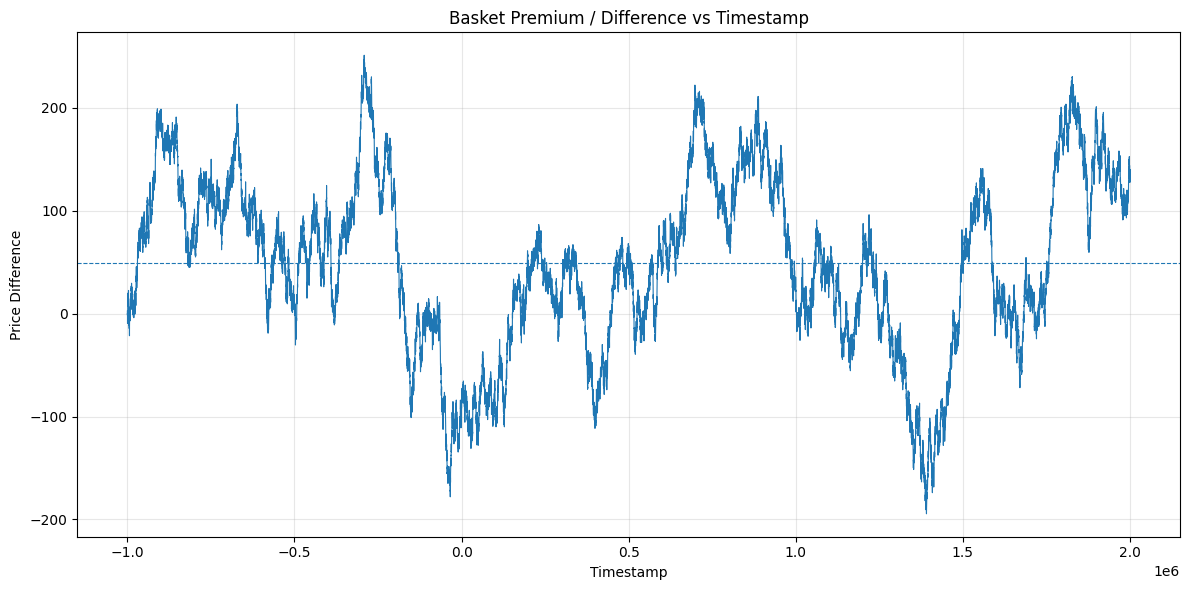

In [ ]:
print("FIRST HALF")
print("---")

full_df = pd.DataFrame(columns=["timestamp", "mid_price"])
first_day = -1

for day in range(first_day, first_day + 3):
    file_path = "r2_d" + str(day) + ".csv"
    df = pd.read_csv(file_path, sep=";")
    df.index = df.index + 80000 * (day - first_day)
    df["timestamp"] = df["timestamp"] + 1000000 * day
    full_df = pd.concat([full_df, df])

print(full_df)

'''
PARAMETERS
'''

df = full_df # for method below, since it uses df
side1_products = ["PICNIC_BASKET1"]
side1_scalars = [1]
side2_products = ["CROISSANTS", "JAMS", "DJEMBES"]
side2_scalars = [6, 3, 1]
    
'''
START OF METHOD
'''

# Clean numeric columns
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
df = df.dropna(subset=["timestamp", "product", "mid_price"])

# Build a pivot table: rows = timestamp, columns = product, values = mid_price
# If there are duplicates for a timestamp/product, take the last observed value.
pivot = df.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
    aggfunc="last",
).sort_index()

# Compute weighted sums for each side
side1_value = pd.Series(0.0, index=pivot.index)
for product, scalar in zip(side1_products, side1_scalars):
    if product not in pivot.columns:
        raise KeyError(f"Product '{product}' not found in market file")
    side1_value = side1_value + pivot[product].fillna(0) * scalar

side2_value = pd.Series(0.0, index=pivot.index)
for product, scalar in zip(side2_products, side2_scalars):
    if product not in pivot.columns:
        raise KeyError(f"Product '{product}' not found in market file")
    side2_value = side2_value + pivot[product].fillna(0) * scalar

difference = side1_value - side2_value
difference_df = difference.reset_index()
difference_df.columns = ["timestamp", "mid_price"]
print(difference_df)

'''
END OF METHOD
'''

difference_df["shifted_price"] = difference_df["mid_price"].shift(-1)
difference_df["shifted_diff"] = (difference_df["mid_price"].shift(-1) - difference_df["mid_price"])
# print(difference_df)

print("Autocor:", auto_correlation(difference_df, "mid_price", "shifted_price", 100))
print("Autocor:", auto_correlation(difference_df, "mid_price", "shifted_diff", 100))
plot_difference(difference_df)